# Decision Tree — Regression

## Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree, export_text
)
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
   
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = './processed' 
OUT_DIR       = '../project/outputs/decision_tree'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/models',  exist_ok=True)

print('Config OK. Output directory:', OUT_DIR)

Config OK. Output directory: ../project/outputs/decision_tree


## Load Pre-Processed Artefacts

In [2]:
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train.csv', index_col=0)
X_val   = pd.read_csv(f'{PROCESSED_DIR}/X_val.csv',   index_col=0)
X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test.csv',  index_col=0)

for df in [X_train, X_val, X_test]:
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].map({'Male': 0, 'Female': 1})

y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val   = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv',   index_col=0).squeeze()
y_reg_test  = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv',  index_col=0).squeeze()


feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()

print('Loaded splits:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')
print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')

Loaded splits:
  Train   64000 rows  49 features
  Val      8000 rows  49 features
  Test     8000 rows  49 features

Regression target  — mean=89.15, std=11.57


## Regression Tree — Predict `exam_score`

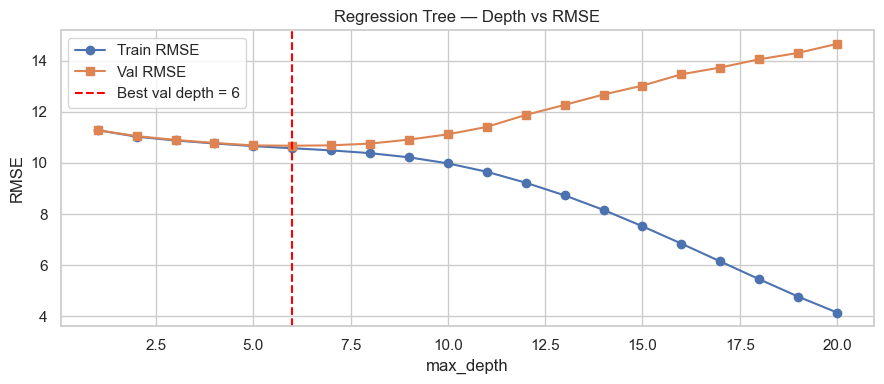

Best depth by val RMSE: 6


In [3]:
depths = range(1, 21)
train_rmse, val_rmse = [], []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_reg_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_reg_train, dt.predict(X_train))))
    val_rmse.append(np.sqrt(mean_squared_error(y_reg_val,   dt.predict(X_val))))

best_depth_manual = depths[np.argmin(val_rmse)]

plt.figure(figsize=(9, 4))
plt.plot(depths, train_rmse, 'o-', label='Train RMSE')
plt.plot(depths, val_rmse,   's-', label='Val RMSE')
plt.axvline(best_depth_manual, color='red', linestyle='--', label=f'Best val depth = {best_depth_manual}')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Regression Tree — Depth vs RMSE')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_depth_vs_rmse.png', dpi=150)
plt.show()
print(f'Best depth by val RMSE: {best_depth_manual}')

In [4]:
param_grid_reg = {
    'max_depth':        [3, 5, 7, 10, 15, None],
    'min_samples_split':[2, 10, 50],
    'min_samples_leaf': [1, 5, 20],
    'max_features':     [None, 'sqrt', 0.5],
}

grid_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_reg.fit(X_train, y_reg_train)

best_reg = grid_reg.best_estimator_
print('Best params:', grid_reg.best_params_)
print(f'Best CV RMSE: {-grid_reg.best_score_:.3f}')

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV RMSE: 10.690


In [5]:
# Evaluate on test set
y_reg_pred = best_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─' * 35)
print(f'  RMSE : {rmse:.3f}')
print(f'  MAE  : {mae:.3f}')
print(f'  R²   : {r2:.4f}')
print('─' * 35)

───────────────────────────────────
  RMSE : 10.823
  MAE  : 8.819
  R²   : 0.1539
───────────────────────────────────


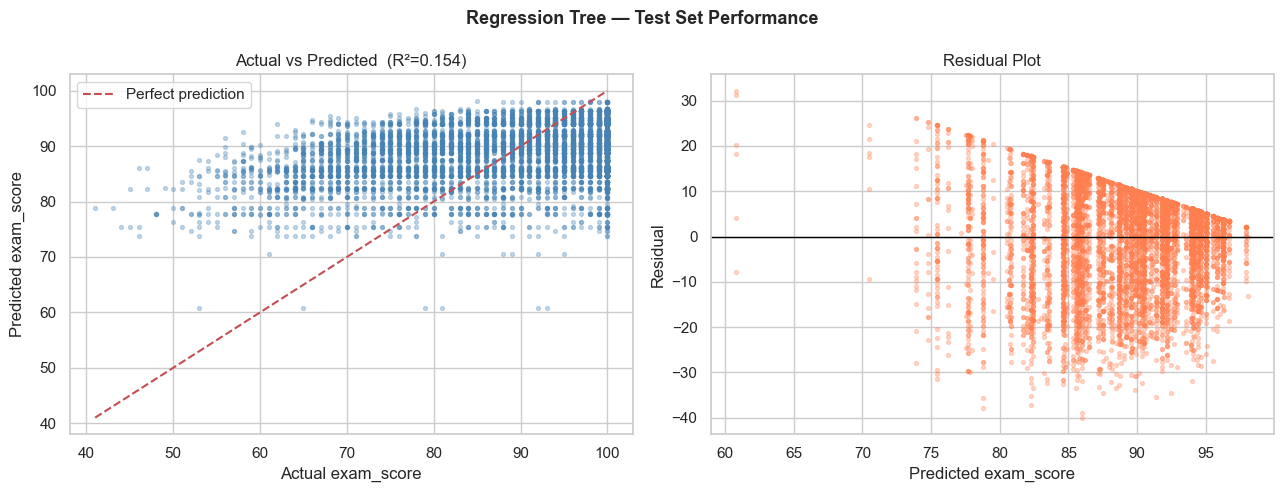

In [6]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=8, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_reg_test - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('Regression Tree — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_actual_vs_predicted.png', dpi=150)
plt.show()

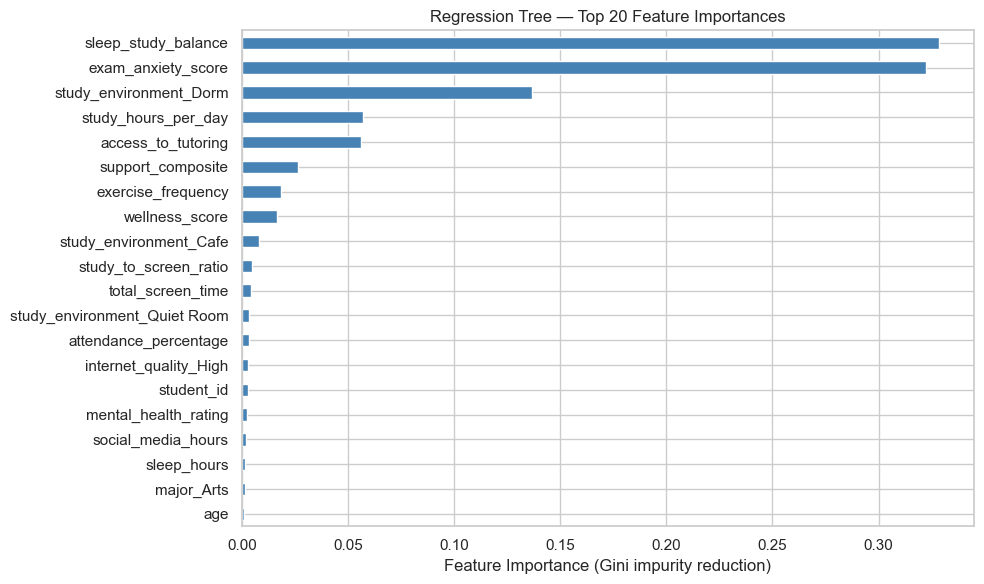

In [7]:
importances = pd.Series(best_reg.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance (Gini impurity reduction)')
plt.title('Regression Tree — Top 20 Feature Importances')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_feature_importances.png', dpi=150)
plt.show()

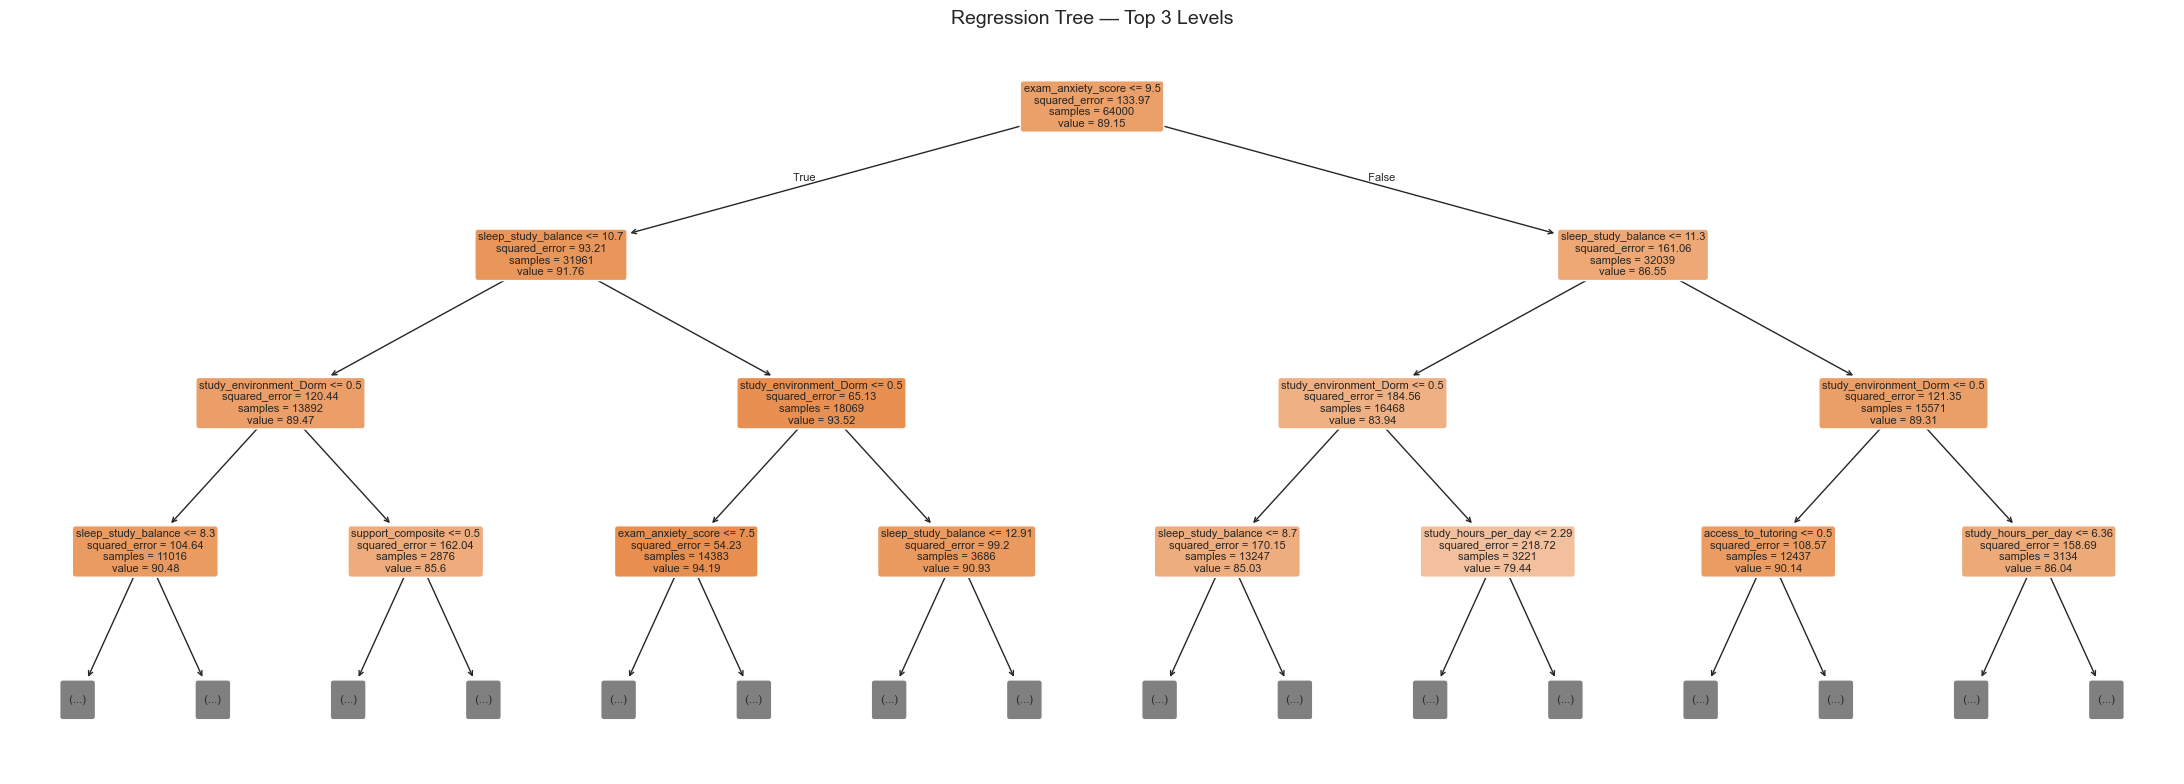

|--- exam_anxiety_score <= 9.50
|   |--- sleep_study_balance <= 10.70
|   |   |--- study_environment_Dorm <= 0.50
|   |   |   |--- sleep_study_balance <= 8.30
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- sleep_study_balance >  8.30
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- study_environment_Dorm >  0.50
|   |   |   |--- support_composite <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- support_composite >  0.50
|   |   |   |   |--- truncated branch of depth 4
|   |--- sleep_study_balance >  10.70
|   |   |--- study_environment_Dorm <= 0.50
|   |   |   |--- exam_anxiety_score <= 7.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- exam_anxiety_score >  7.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- study_environment_Dorm >  0.50
|   |   |   |--- sleep_study_balance <= 12.91
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- sleep_study_balance >  12.91
|   |   |   |   |

In [8]:
plt.figure(figsize=(22, 8))
plot_tree(
    best_reg,
    feature_names=feature_names,
    filled=True,
    max_depth=3,        
    fontsize=8,
    rounded=True,
    impurity=True,
    precision=2
)
plt.title('Regression Tree — Top 3 Levels', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_tree_viz.png', dpi=150, bbox_inches='tight')
plt.show()

tree_text = export_text(best_reg, feature_names=feature_names, max_depth=3)
print(tree_text)

In [9]:
joblib.dump(best_reg, f'{OUT_DIR}/models/reg_decision_tree.joblib')
print('Regression tree saved.')

Regression tree saved.


---
## Results Summary

In [10]:
summary = pd.DataFrame([
    {
        'Task':          'Regression (exam_score)',
        'Best Params':   str(grid_reg.best_params_),
        'CV Score':      f'RMSE = {-grid_reg.best_score_:.3f}',
        'Test RMSE':     f'{rmse:.3f}',
        'Test MAE':      f'{mae:.3f}',
        'Test R²':       f'{r2:.4f}',
    }
])
display(summary)

print('\nAll figures saved to:', f'{OUT_DIR}/figures/')
print('All models saved to: ', f'{OUT_DIR}/models/')

,Task,Best Params,CV Score,Test RMSE,Test MAE,Test R²
0,Regression (exam_score),"{'max_depth': 7, 'max_features': None, 'min_sa...",RMSE = 10.690,10.823,8.819,0.1539



All figures saved to: ../project/outputs/decision_tree/figures/
All models saved to:  ../project/outputs/decision_tree/models/
